CLIP-SWIN Hybrid Model

In [1]:
!pip install colorama

In [2]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [5]:
!kaggle datasets download -d viswachaitanyasai/deepfake-dataset
!unzip deepfake-dataset.zip -d /deepfake-dataset

Streaming output truncated to the last 5000 lines.
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3505.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3506.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3507.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3508.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3509.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3510.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3511.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3512.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3513.jpg  
  inflating: /deepfake-dataset/deepfake_dataset/validation/ffpp/fake/validation_3514.jpg  
  inflating: /deepfake-dataset/deepfake

In [7]:
%pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-hjrx7n5q
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-hjrx7n5q
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
#!/usr/bin/env python
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torchvision import datasets, transforms
import timm
import clip  
import logging
from tqdm import tqdm
import torch.nn.functional as F
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from albumentations import (
    Compose, RandomRotate90, Transpose, HorizontalFlip, VerticalFlip,
    GaussNoise, ShiftScaleRotate, CLAHE, Sharpen, Emboss, RandomBrightnessContrast,
    HueSaturationValue, OneOf
)
from albumentations.pytorch import ToTensorV2
from PIL import Image

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

##############################################
#         Advanced Data Augmentation         #
##############################################
def strong_aug(p=0.5):
    return Compose([
        RandomRotate90(p=0.2),
        Transpose(p=0.2),
        HorizontalFlip(p=0.5),
        VerticalFlip(p=0.5),
        OneOf([GaussNoise()], p=0.2),
        ShiftScaleRotate(p=0.2),
        OneOf([
            CLAHE(clip_limit=2),
            Sharpen(),
            Emboss(),
            RandomBrightnessContrast(),
        ], p=0.2),
        HueSaturationValue(p=0.2),
    ], p=p)

def augment(aug, image):
    return aug(image=np.array(image))["image"]

class Aug(object):
    def __call__(self, img):
        aug_inst = strong_aug(p=0.9)
        aug_img = augment(aug_inst, img)
        return Image.fromarray(aug_img)

##############################################
#            Data Transforms                 #
##############################################
def normalize_data():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return {
        "train": transforms.Compose([
            Aug(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        "valid": transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        "test": transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

##############################################
#            Data Handling (Updated)         #
##############################################
base_dataset_dir = '/deepfake-dataset/deepfake_dataset'  
sub_datasets = ["celebdf", "dfdc", "ffpp", "realfake"]

transforms_dict = normalize_data()

train_datasets = []
val_datasets = []
test_datasets = []

for sub in sub_datasets:
    train_path = os.path.join(base_dataset_dir, "train", sub)
    val_path   = os.path.join(base_dataset_dir, "validation", sub)
    test_path  = os.path.join(base_dataset_dir, "test", sub)

    train_datasets.append(datasets.ImageFolder(train_path, transform=transforms_dict["train"]))
    val_datasets.append(datasets.ImageFolder(val_path, transform=transforms_dict["valid"]))
    test_datasets.append(datasets.ImageFolder(test_path, transform=transforms_dict["test"]))

full_train_dataset = ConcatDataset(train_datasets)
full_val_dataset   = ConcatDataset(val_datasets)
full_test_dataset  = ConcatDataset(test_datasets)

train_subset_size = 20000
val_subset_size   = 5000

train_indices = random.sample(range(len(full_train_dataset)), train_subset_size)
val_indices   = random.sample(range(len(full_val_dataset)), val_subset_size)

train_subset = Subset(full_train_dataset, train_indices)
val_subset   = Subset(full_val_dataset, val_indices)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(full_test_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples: {len(full_test_dataset)}")

##############################################
#      Model Components & Enhanced Modules   #
##############################################
# Enhanced Attention Fusion with added non-linearity after projection.
class AttentionFusion(nn.Module):
    """
    Projects each branch's feature to a common dimension, applies a ReLU,
    then learns attention scores to fuse them.
    """
    def __init__(self, input_dims, common_dim=256):
        super(AttentionFusion, self).__init__()
        self.proj_layers = nn.ModuleList([nn.Linear(dim, common_dim) for dim in input_dims])
        self.relu = nn.ReLU()
        self.attn_fc = nn.Linear(common_dim, 1)  # scalar score per branch

    def forward(self, features):
        proj_features = [self.relu(proj(f)) for f, proj in zip(features, self.proj_layers)]  
        scores = [self.attn_fc(f) for f in proj_features]  # each: [B, 1]
        scores = torch.cat(scores, dim=1)  # [B, num_branches]
        weights = torch.softmax(scores, dim=1)  # [B, num_branches]
        fused = sum(weights[:, i:i+1] * proj_features[i] for i in range(len(proj_features)))
        return fused, weights

# Frequency branch remains as before.
class FrequencyBranch(nn.Module):
    def __init__(self, output_dim=256):
        super(FrequencyBranch, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, output_dim)

    def forward(self, x):
        fft = torch.fft.fft2(x, norm='ortho')
        fft = torch.abs(fft)
        fft = torch.log(fft + 1.0)
        out = self.conv(fft)
        out = self.avgpool(out).view(out.size(0), -1)
        out = self.fc(out)
        return out

# Hybrid Model combining Swin, CLIP, and Frequency Branches.
class HybridDeepfakeDetector(nn.Module):
    def __init__(self, num_classes=1, device=device):
        super(HybridDeepfakeDetector, self).__init__()
        self.clip, _ = clip.load("ViT-B/32", device=device)
        self.clip.float()
        self.swin = timm.create_model('swin_small_patch4_window7_224', pretrained=True)
        self.swin = self.swin.to(device)  

        if hasattr(self.swin, 'head'):
            self.swin.head = nn.Identity()
        elif hasattr(self.swin, 'fc'):
            self.swin.fc = nn.Identity()

        dummy = torch.randn(1, 3, 224, 224).to(device)
        with torch.no_grad():
            clip_feat = self.clip.encode_image(dummy)
            if clip_feat.ndim == 4:
                clip_feat = F.adaptive_avg_pool2d(clip_feat, 1).view(1, -1)
            swin_feat = self.swin.forward_features(dummy) if hasattr(self.swin, 'forward_features') else self.swin(dummy)
            if swin_feat.ndim == 4:
                swin_feat = F.adaptive_avg_pool2d(swin_feat, 1).view(1, -1)
            self.clip_dim = clip_feat.shape[1]
            self.swin_dim = swin_feat.shape[1]
            logging.info(f"CLIP feature dim: {self.clip_dim}")
            logging.info(f"Swin feature dim: {self.swin_dim}")
            print(f"CLIP feature dim: {self.clip_dim}")
            print(f"Swin feature dim: {self.swin_dim}")

        self.freq_branch = FrequencyBranch(output_dim=256)
        freq_dim = 256

        fusion_input_dims = [self.clip_dim, self.swin_dim, freq_dim]
        self.attn_fusion = AttentionFusion(input_dims=fusion_input_dims, common_dim=256)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        clip_feat = self.clip.encode_image(x)
        if clip_feat.ndim == 4:
            clip_feat = F.adaptive_avg_pool2d(clip_feat, 1).view(x.size(0), -1)
        swin_feat = self.swin.forward_features(x) if hasattr(self.swin, 'forward_features') else self.swin(x)
        if swin_feat.ndim == 4:
            swin_feat = F.adaptive_avg_pool2d(swin_feat, 1).view(x.size(0), -1)
        freq_feat = self.freq_branch(x)
        fused_feat, attn_weights = self.attn_fusion([clip_feat, swin_feat, freq_feat])
        out = self.classifier(fused_feat)
        return out, attn_weights

model = HybridDeepfakeDetector(num_classes=1, device=device)

if torch.cuda.device_count() > 1:
    logging.info(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model = model.to(device)
print("Hybrid Deepfake Detector (Swin + CLIP + Frequency) created.")

##############################################
#        Optimizer, Loss & Scheduler         #
##############################################
pos_weight_value = 10667 / 9333
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=0)

num_epochs = 15  
steps_per_epoch = len(train_loader)
total_steps = num_epochs * steps_per_epoch
scheduler = OneCycleLR(optimizer, max_lr=1e-4, total_steps=total_steps, pct_start=0.1, anneal_strategy='cos')

##############################################
#         Threshold Optimization Function    #
##############################################
def optimize_threshold(probs, true_labels):
    best_thresh = 0.5
    best_acc = 0.0
    for t in np.arange(0.0, 1.0, 0.01):
        preds = (probs >= t).astype(int)
        acc = accuracy_score(true_labels, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = t
    return best_thresh, best_acc

##############################################
#         Training & Validation Loops        #
##############################################
scaler = torch.amp.GradScaler(device=device)  
best_val_loss = float('inf')
patience = 5
trigger_times = 0

train_history = {"loss": [], "acc": []}
val_history = {"loss": [], "acc": []}

dataset_sizes = {
    "train": len(train_loader.dataset),
    "validation": len(val_loader.dataset),
    "test": len(test_loader.dataset)
}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Training", leave=False)
    for images, labels in train_bar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=device):
            outputs, _ = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).int()
        train_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        train_total += labels.size(0)
        train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{(train_correct/train_total):.4f}")
    epoch_loss = running_loss / dataset_sizes["train"]
    train_acc = train_correct / train_total
    train_history["loss"].append(epoch_loss)
    train_history["acc"].append(train_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_probs = []
    val_true = []
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validation", leave=False)
    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            with torch.amp.autocast(device_type=device):
                outputs, _ = model(images)
                loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)
            val_probs.extend(probs.cpu().numpy().flatten())
            preds = (probs > 0.5).int()
            val_correct += (preds.cpu() == labels.cpu().int()).sum().item()
            val_total += labels.size(0)
            val_true.extend(labels.cpu().numpy().flatten())
            val_bar.set_postfix(loss=f"{loss.item():.4f}")
    epoch_val_loss = val_loss / dataset_sizes["validation"]
    epoch_val_acc = val_correct / val_total
    val_history["loss"].append(epoch_val_loss)
    val_history["acc"].append(epoch_val_acc)

    best_thresh, best_val_acc = optimize_threshold(np.array(val_probs), np.array(val_true))

    val_preds = (np.array(val_probs) >= best_thresh).astype(int)
    val_accuracy = accuracy_score(val_true, val_preds)
    val_precision = precision_score(val_true, val_preds)
    val_recall = recall_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds)
    try:
        val_auc = roc_auc_score(val_true, val_probs)
    except Exception:
        val_auc = 0.0

    logging.info(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.4f}")
    logging.info(f"                Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, Best Thresh: {best_thresh:.2f}")
    logging.info(f"                Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"                Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}, Best Thresh: {best_thresh:.2f}")
    print(f"                Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}, AUC: {val_auc:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        trigger_times = 0
        torch.save(model.state_dict(), "best_hybrid_model.pth")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            logging.info("Early stopping triggered!")
            break

##############################################
#         Plotting Function                    #
##############################################
def plot_graph(metric_history, metric_name):
    plt.figure(figsize=(10, 5))
    plt.plot(metric_history, label=metric_name)
    plt.title(f"{metric_name} Trend")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.legend()
    plt.show()

plot_graph(train_history["loss"], "Train Loss", "hybrid")
plot_graph(train_history["acc"], "Train Accuracy", "hybrid")
plot_graph(val_history["loss"], "Validation Loss", "hybrid")
plot_graph(val_history["acc"], "Validation Accuracy", "hybrid")

##############################################
#         Testing & Evaluation               #
##############################################
model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))
model.eval()

test_probs = []
all_preds = []
all_labels = []
test_loss = 0.0
test_correct = 0
test_total = 0
test_bar = tqdm(test_loader, desc="Testing", leave=False)

with torch.no_grad():
    for images, labels in test_bar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        with torch.amp.autocast(device_type=device):
            outputs, _ = model(images)  
            loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)
        test_probs.extend(probs.cpu().numpy().flatten())
        preds = (probs > best_thresh).int()  
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
        test_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        test_total += labels.size(0)
        test_bar.set_postfix(loss=f"{loss.item():.4f}")

test_loss /= dataset_sizes["test"]
test_acc = test_correct / test_total

final_preds = (np.array(test_probs) >= best_thresh).astype(int)
final_labels = np.array(all_labels).astype(int)

accuracy_metric = accuracy_score(final_labels, final_preds)
precision_metric = precision_score(final_labels, final_preds)
recall_metric = recall_score(final_labels, final_preds)
f1_metric = f1_score(final_labels, final_preds)
conf_matrix = confusion_matrix(final_labels, final_preds)
try:
    auc_metric = roc_auc_score(final_labels, test_probs)
except Exception:
    auc_metric = "N/A"
classification_rep = classification_report(final_labels, final_preds)

print("\n=== Test Evaluation Metrics ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy_metric:.4f}")
print(f"Precision: {precision_metric:.4f}")
print(f"Recall: {recall_metric:.4f}")
print(f"F1 Score: {f1_metric:.4f}")
print(f"ROC-AUC: {auc_metric}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Using device: cuda
Train samples: 20000
Validation samples: 5000
Test samples: 8344


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


CLIP feature dim: 512
Swin feature dim: 7
Hybrid Deepfake Detector (Swin + CLIP + Frequency) created.


Epoch 1/15 - Training:   0%|          | 0/1250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch [1/15] - Train Loss: 0.6895, Train Acc: 0.6338
                Val Loss: 0.6655, Val Acc: 0.6714, Best Thresh: 0.30
                Precision: 0.6446, Recall: 0.8013, F1: 0.7145, AUC: 0.7483


...

Epoch 14/15 - Training:   0%|          | 0/1250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch [14/15] - Train Loss: 0.2065, Train Acc: 0.9198
                Val Loss: 0.2149, Val Acc: 0.9218, Best Thresh: 0.43
                Precision: 0.9173, Recall: 0.9209, F1: 0.9191, AUC: 0.9798


Epoch 15/15 - Training:   0%|          | 0/1250 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Epoch [15/15] - Train Loss: 0.2052, Train Acc: 0.9211
                Val Loss: 0.2182, Val Acc: 0.9230, Best Thresh: 0.34
                Precision: 0.9049, Recall: 0.9368, F1: 0.9205, AUC: 0.9798


TypeError: plot_graph() takes 2 positional arguments but 3 were given

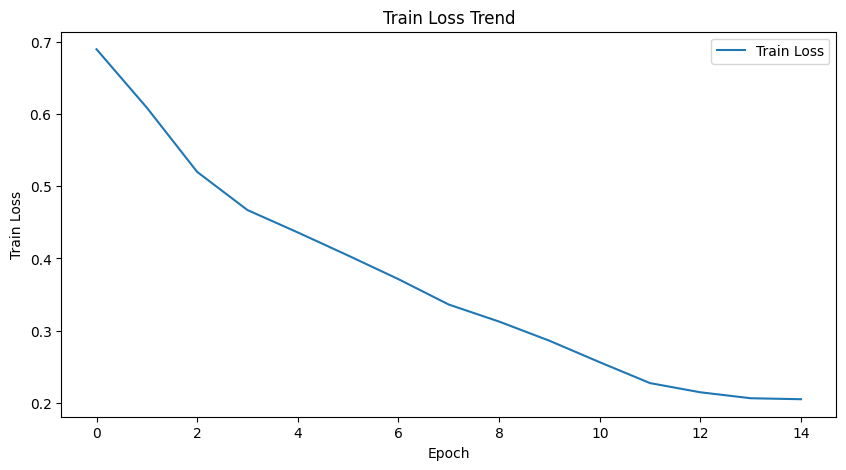

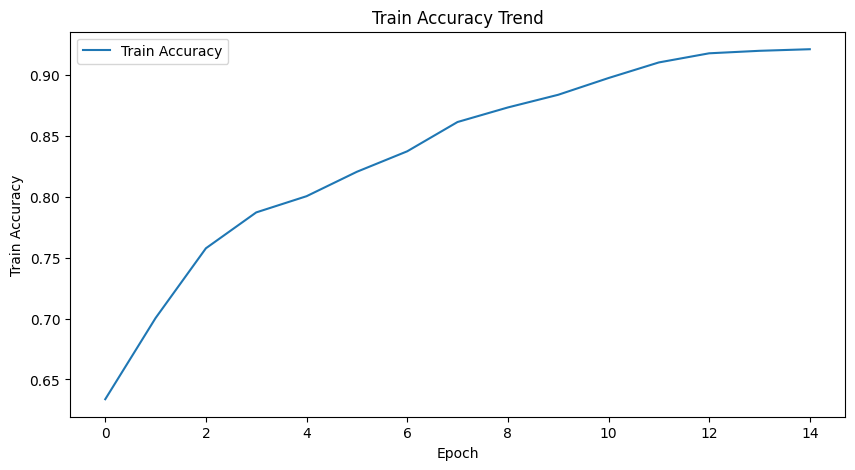

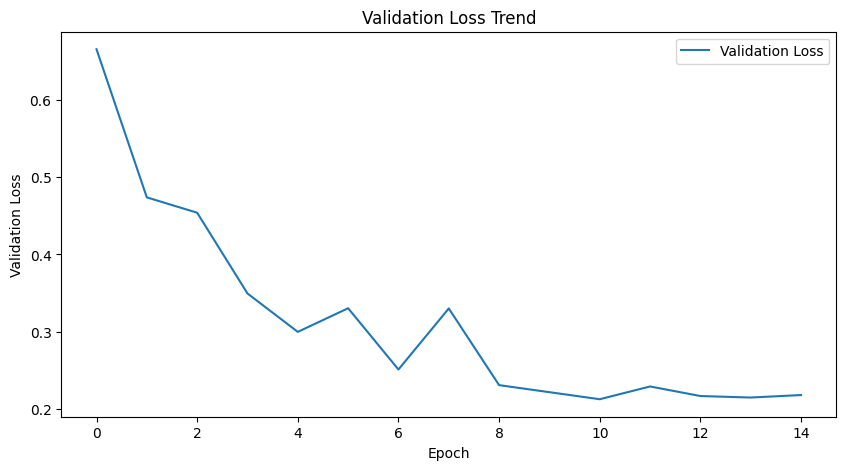

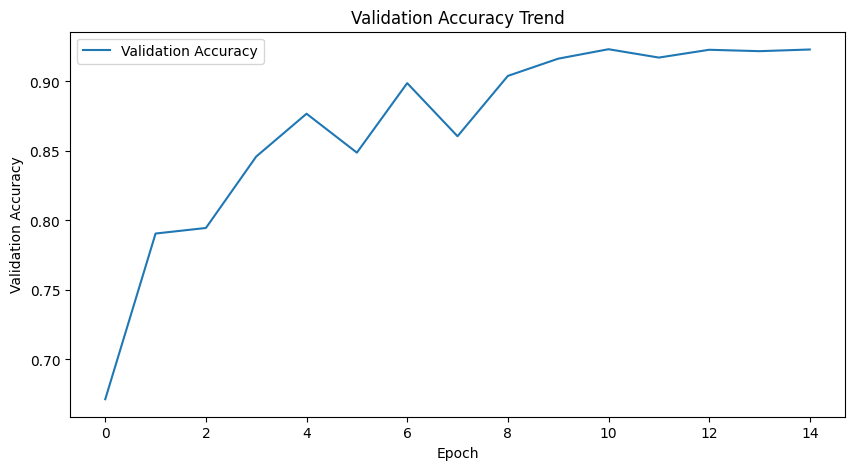


=== Test Evaluation Metrics ===
Test Loss: 0.2355
Test Accuracy: 0.9111
Precision: 0.8704
Recall: 0.9499
F1 Score: 0.9084
ROC-AUC: 0.9740698328442124
Confusion Matrix:
[[3922  548]
 [ 194 3680]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      4470
           1       0.87      0.95      0.91      3874

    accuracy                           0.91      8344
   macro avg       0.91      0.91      0.91      8344
weighted avg       0.91      0.91      0.91      8344



In [ ]:
def plot_graph(metric_history, metric_name):
    plt.figure(figsize=(10, 5))
    plt.plot(metric_history, label=metric_name)
    plt.title(f"{metric_name} Trend")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.legend()
    plt.show()

plot_graph(train_history["loss"], "Train Loss")
plot_graph(train_history["acc"], "Train Accuracy")
plot_graph(val_history["loss"], "Validation Loss")
plot_graph(val_history["acc"], "Validation Accuracy")
model.load_state_dict(torch.load("best_hybrid_model.pth", map_location=device))
model.eval()

test_probs = []
all_preds = []
all_labels = []
test_loss = 0.0
test_correct = 0
test_total = 0
test_bar = tqdm(test_loader, desc="Testing", leave=False)

with torch.no_grad():
    for images, labels in test_bar:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        with torch.amp.autocast(device_type=device):
            outputs, _ = model(images)  
            loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(outputs)
        test_probs.extend(probs.cpu().numpy().flatten())
        preds = (probs > best_thresh).int()  
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
        test_correct += (preds.cpu() == labels.cpu().int()).sum().item()
        test_total += labels.size(0)
        test_bar.set_postfix(loss=f"{loss.item():.4f}")

test_loss /= dataset_sizes["test"]
test_acc = test_correct / test_total

final_preds = (np.array(test_probs) >= best_thresh).astype(int)
final_labels = np.array(all_labels).astype(int)

accuracy_metric = accuracy_score(final_labels, final_preds)
precision_metric = precision_score(final_labels, final_preds)
recall_metric = recall_score(final_labels, final_preds)
f1_metric = f1_score(final_labels, final_preds)
conf_matrix = confusion_matrix(final_labels, final_preds)
try:
    auc_metric = roc_auc_score(final_labels, test_probs)
except Exception:
    auc_metric = "N/A"
classification_rep = classification_report(final_labels, final_preds)

print("\n=== Test Evaluation Metrics ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy_metric:.4f}")
print(f"Precision: {precision_metric:.4f}")
print(f"Recall: {recall_metric:.4f}")
print(f"F1 Score: {f1_metric:.4f}")
print(f"ROC-AUC: {auc_metric}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)